In [2]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import seaborn as sns

data = fetch_california_housing(as_frame=True)
df = data.frame
df = df.dropna()
print(data.DESCR)
df.head()


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
features  = ["Latitude", "Longitude", "MedHouseVal"]
X = df[features]


In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans_labels = kmeans.fit_predict(X_scaled)
df["MedHouseVal"] = kmeans_labels

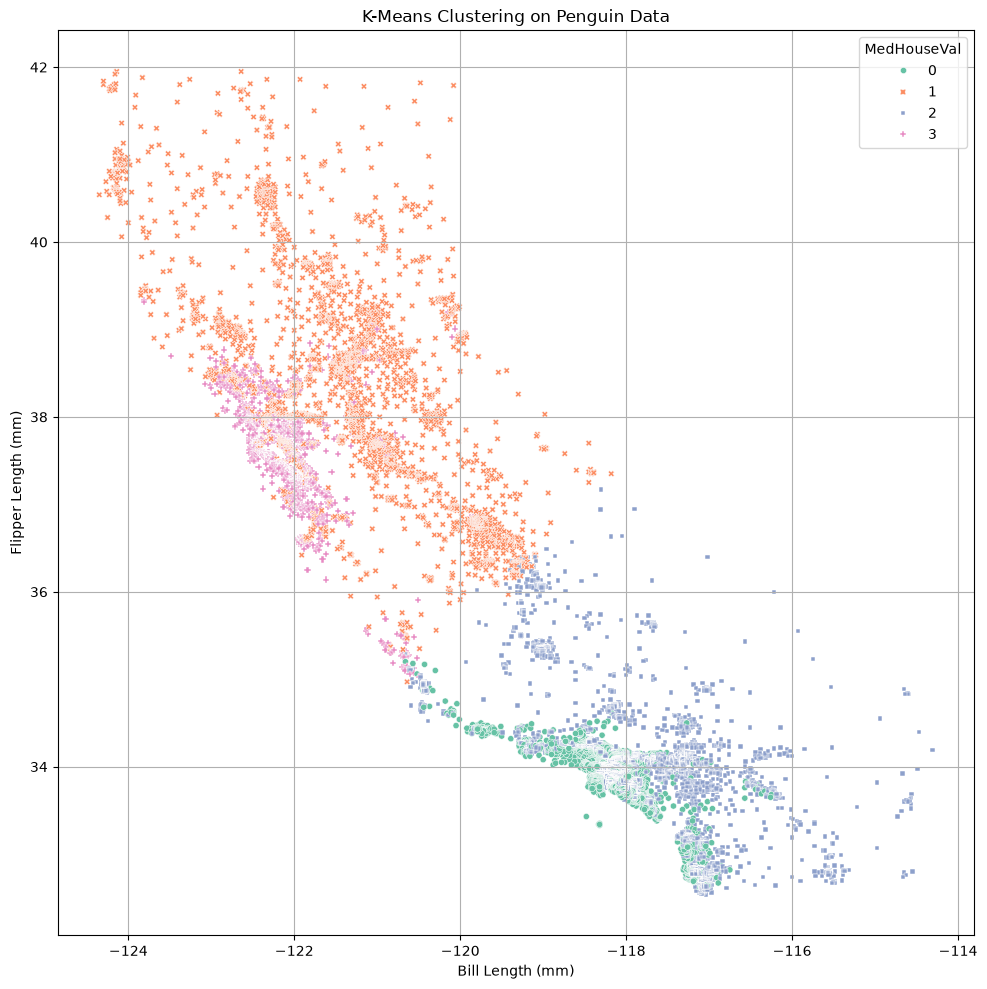

In [9]:
import matplotlib.pyplot as plt

# Plot the clustering result (on two principal features for simplicity)
# Color = the cluster k-means found (Steps 2-4); marker shape = the true
# species. If the two mostly agree, the clusters recovered real structure.
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x="Longitude", y="Latitude", hue = "MedHouseVal", palette="Set2", style="MedHouseVal",s=20)
plt.title("K-Means Clustering on Penguin Data")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

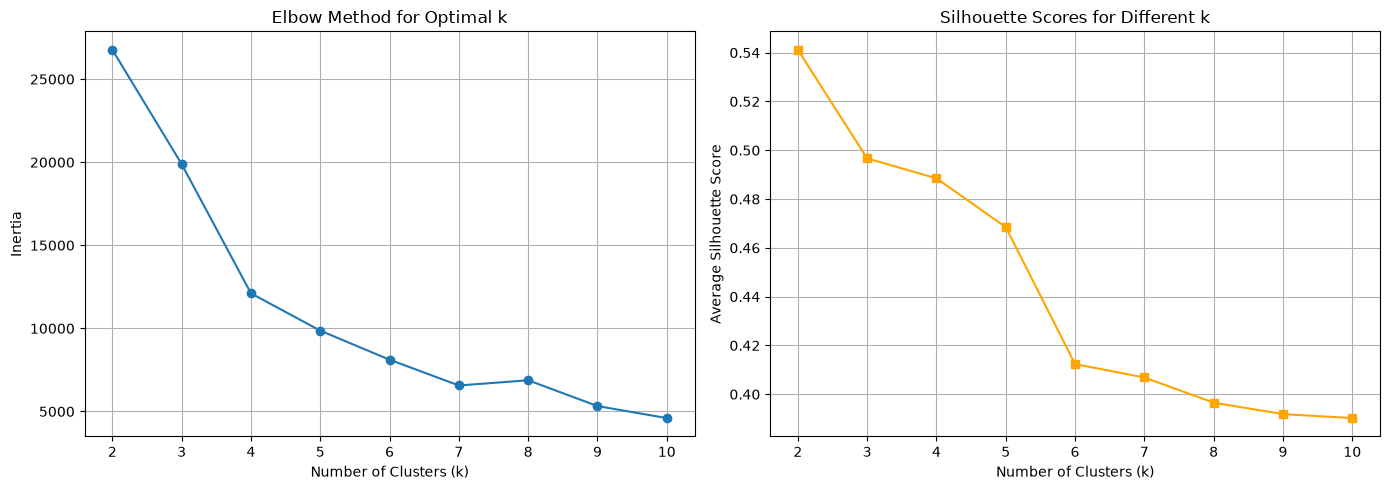

In [28]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_) # obtain the inertia (sum of squared distances to closest cluster center)
    silhouette_scores.append(silhouette_score(X_scaled, labels)) # obtain the silhouette score

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axs[0].plot(K_range, inertias, marker='o')
axs[0].set_title("Elbow Method for Optimal k")
axs[0].set_xlabel("Number of Clusters (k)")
axs[0].set_ylabel("Inertia")
axs[0].grid(True)

# Silhouette plot
axs[1].plot(K_range, silhouette_scores, marker='s', color='orange')
axs[1].set_title("Silhouette Scores for Different k")
axs[1].set_xlabel("Number of Clusters (k)")
axs[1].set_ylabel("Average Silhouette Score")
axs[1].grid(True)

plt.tight_layout()
plt.show()